# The Climate is Changing: How is Our Sentiment?

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

### This is a notebook for exploring stopwords in the climate corpus. 

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Imports

In [1]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.lancaster import LancasterStemmer



# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
%%capture
%run notebooks/create_tables.ipynb

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### View Stopwords

In [3]:
# Define and view some sample stopwords according to NLTK
sw = pd.DataFrame(nltk.corpus.stopwords.words('english'), columns=['term_str'])
sw = sw.reset_index().set_index('term_str')
sw.columns = ['dummy']
sw.dummy = 1
sw.sample(5)

,dummy
term_str,
again,1
what,1
hasn't,1
be,1
how,1


In [4]:
VOCAB['stop'] = sw
VOCAB['stop'] = VOCAB['stop'].fillna(0).astype('int')
# View stopwords in the corpus
VOCAB[VOCAB.stop == 1]

n         p          i      p_yr       i_yr  stop
year term_str                                                      
2013 the       4963  0.009662   6.693500  0.059097   4.080779     1
     of        3106  0.006047   7.369654  0.036985   4.756933     1
     and       2631  0.005122   7.609101  0.031329   4.996380     1
     in        2310  0.004497   7.796819  0.027506   5.184098     1
     to        1710  0.003329   8.230716  0.020362   5.617995     1
...             ...       ...        ...       ...        ...   ...
2023 you          4  0.000008  16.970496  0.000017  15.864035     1
     won          3  0.000006  17.385534  0.000013  16.279072     1
     doing        3  0.000006  17.385534  0.000013  16.279072     1
     whom         1  0.000002  18.970496  0.000004  17.864035     1
     don          1  0.000002  18.970496  0.000004  17.864035     1

[356 rows x 6 columns]

Stopwords tend to have high information. 

In [5]:
# Average stopwords per year
print("Total Stopwords in Corpus:", int(VOCAB.stop.sum()))
print("Total Stopwords in 2013:", int(VOCAB[VOCAB.index.get_level_values('year') == '2013'].stop.sum()))
print("Total Stopwords in 2018:", int(VOCAB[VOCAB.index.get_level_values('year') == '2018'].stop.sum()))
print("Total Stopwords in 2023:", int(VOCAB[VOCAB.index.get_level_values('year') == '2023'].stop.sum()))

Total Stopwords in Corpus: 356
Total Stopwords in 2013: 117
Total Stopwords in 2018: 122
Total Stopwords in 2023: 117


There are a similar number of stopwords per year - not much of an observable pattern other than this similarity!

In [6]:
VOCAB_nosw = VOCAB[VOCAB['stop'] == 0]

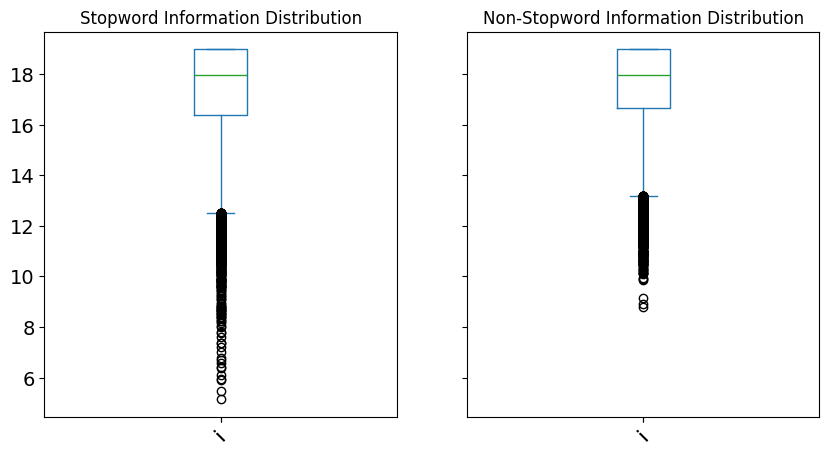

In [7]:
# Box plot of stopword and non-sw information
fig0, (ax1, ax2) = plt.subplots(1,2, sharex='all', sharey='all')

VOCAB['i'].plot.box(ax=ax1, figsize=(10,5), fontsize=14, rot=45, legend=False, title="Stopword Information Distribution")
VOCAB_nosw['i'].plot.box(ax=ax2, figsize=(10,5), fontsize=14, rot=45, legend=False, title="Non-Stopword Information Distribution")

plt.show()

Stopwords and non-stopwords generally both have high information and have very similar means, but stopwords have a longer, lower tail. 

In [8]:
VOCAB

n         p          i      p_yr       i_yr  stop
year term_str                                                          
2013 the           4963  0.009662   6.693500  0.059097   4.080779     1
     of            3106  0.006047   7.369654  0.036985   4.756933     1
     and           2631  0.005122   7.609101  0.031329   4.996380     1
     in            2310  0.004497   7.796819  0.027506   5.184098     1
     to            1710  0.003329   8.230716  0.020362   5.617995     1
...                 ...       ...        ...       ...        ...   ...
2023 scpi             1  0.000002  18.970496  0.000004  17.864035     0
     fba              1  0.000002  18.970496  0.000004  17.864035     0
     sip11            1  0.000002  18.970496  0.000004  17.864035     0
     eno              1  0.000002  18.970496  0.000004  17.864035     0
     conclusively     1  0.000002  18.970496  0.000004  17.864035     0

[40776 rows x 6 columns]

### View Statistics of Stopwords

In [9]:
# Add n_chars, pos
VOCAB['n_chars'] = VOCAB.index.get_level_values("term_str").str.len()
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
# Explore the means
VOCAB.groupby('stop').agg({'n_chars':'mean', 'n_pos':'mean'})

,n_chars,n_pos
stop,,
0,7.789683,1.532583
1,3.606742,2.401685


Non-stopwords tend to be over twice as long as stopwords. This makes sense given the long terminology (non-stopwords) used in science. They have slightly fewer (but not by much) numbers of parts of speech, perhaps because scientific literature uses such specific words that have very few possible parts of speech.

### Comparing Stopword Usage Across Years

In [10]:
YEAR = CORPUS.merge(LIB.reset_index()[['doc_id','year']], on='doc_id')\
    .merge(VOCAB.reset_index()[['term_str', 'stop']], on='term_str')\
    .groupby(['year','stop']).agg('sum', numeric_only=True).unstack()
YEAR.columns = YEAR.columns.droplevel(0)
(YEAR.T / YEAR.T.sum()).T.style.background_gradient(axis=None)

stop,0,1
year,,
2013,0.602500,0.397500
2018,0.595456,0.404544
2023,0.605488,0.394512


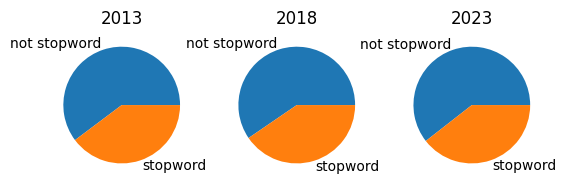

In [11]:
# Some help from Claude here

axes = (YEAR.T / YEAR.T.sum()).plot.pie(subplots=True, legend=False, labels=['not stopword', 'stopword'])

for ax, year in zip(axes, YEAR.index):
    ax.set_title(year)

sns.despine()
plt.show()

Values do not differ greatly by year.

### Explore Stems

In [12]:
VOCAB

n         p          i      p_yr       i_yr  stop  \
year term_str                                                             
2013 the           4963  0.009662   6.693500  0.059097   4.080779     1   
     of            3106  0.006047   7.369654  0.036985   4.756933     1   
     and           2631  0.005122   7.609101  0.031329   4.996380     1   
     in            2310  0.004497   7.796819  0.027506   5.184098     1   
     to            1710  0.003329   8.230716  0.020362   5.617995     1   
...                 ...       ...        ...       ...        ...   ...   
2023 scpi             1  0.000002  18.970496  0.000004  17.864035     0   
     fba              1  0.000002  18.970496  0.000004  17.864035     0   
     sip11            1  0.000002  18.970496  0.000004  17.864035     0   
     eno              1  0.000002  18.970496  0.000004  17.864035     0   
     conclusively     1  0.000002  18.970496  0.000004  17.864035     0   

                   n_chars  n_pos  
year term_str                      
2013 the                 3      2  
     of                  2      3  
     and                 3      2  
     in                  2      2  
     to                  2      2  
...                    ...    ...  
2023 scpi                4      1  
     fba                 3      1  
     sip11               5      1  
     eno                 3      1  
     conclusively       12      1  

[40776 rows x 8 columns]

In [13]:
# Porter stemmer
VOCAB['stem_porter'] = VOCAB.apply(lambda x: PorterStemmer().stem(x.name[-1]), 1) # [-1] from Claude

# Snowball stemmer (English)
VOCAB['stem_snowball'] = VOCAB.apply(lambda x: SnowballStemmer("english").stem(x.name[-1]), 1)

# Lancaster stemmer
VOCAB['stem_lancaster'] = VOCAB.apply(lambda x: LancasterStemmer().stem(x.name[-1]), 1)

# View
VOCAB.sample(10)

n         p          i      p_yr       i_yr  stop  n_chars  \
year term_str                                                                  
2018 reads       19  0.000037  14.722569  0.000099  13.296245     0        5   
     habits       8  0.000016  15.970496  0.000042  14.544172     0        6   
     ferder       1  0.000002  18.970496  0.000005  17.544172     0        6   
     pleurodont   1  0.000002  18.970496  0.000005  17.544172     0       10   
2023 0666         1  0.000002  18.970496  0.000004  17.864035     0        4   
2018 graphs       1  0.000002  18.970496  0.000005  17.544172     0        6   
2023 bobwhite     1  0.000002  18.970496  0.000004  17.864035     0        8   
     pnjr         3  0.000006  17.385534  0.000013  16.279072     0        4   
     gorgonia     1  0.000002  18.970496  0.000004  17.864035     0        8   
2018 ternary      8  0.000016  15.970496  0.000042  14.544172     0        7   

                 n_pos stem_porter stem_snowball stem_lancaster  
year term_str                                                    
2018 reads           2        read          read           read  
     habits          1       habit         habit          habit  
     ferder          1      ferder        ferder           ferd  
     pleurodont      1  pleurodont    pleurodont     pleurodont  
2023 0666            1        0666          0666           0666  
2018 graphs          3       graph         graph          graph  
2023 bobwhite        2     bobwhit       bobwhit        bobwhit  
     pnjr            1        pnjr          pnjr           pnjr  
     gorgonia        1    gorgonia      gorgonia         gorgon  
2018 ternary         1     ternari       ternari           tern

In [14]:
# View differences
VOCAB[VOCAB.stem_porter != VOCAB.stem_lancaster]

n         p          i      p_yr       i_yr  stop  \
year term_str                                                              
2013 were            674  0.001312   9.573892  0.008026   6.961171     1   
     was             550  0.001071   9.867209  0.006549   7.254488     1   
     are             496  0.000966  10.016300  0.005906   7.403579     1   
     species         461  0.000897  10.121873  0.005489   7.509152     0   
     have            270  0.000526  10.893681  0.003215   8.280960     1   
...                  ...       ...        ...       ...        ...   ...   
2023 responsiveness    1  0.000002  18.970496  0.000004  17.864035     0   
     floating          1  0.000002  18.970496  0.000004  17.864035     0   
     spiral            1  0.000002  18.970496  0.000004  17.864035     0   
     foreseeing        1  0.000002  18.970496  0.000004  17.864035     0   
     conclusively      1  0.000002  18.970496  0.000004  17.864035     0   

                     n_chars  n_pos stem_porter stem_snowball stem_lancaster  
year term_str                                                                 
2013 were                  4      1        were          were            wer  
     was                   3      1          wa           was            was  
     are                   3      2         are           are             ar  
     species               7      6       speci         speci          specy  
     have                  4      2        have          have            hav  
...                      ...    ...         ...           ...            ...  
2023 responsiveness       14      1     respons       respons        respond  
     floating              8      2       float         float            flo  
     spiral                6      1      spiral        spiral           spir  
     foreseeing           10      1      forese        forese          fores  
     conclusively         12      1     conclus       conclus        conclud  

[15491 rows x 11 columns]

### Remove Stopwords

In [15]:
# Duplicate line just to keep logic clear
VOCAB_nosw = VOCAB[VOCAB['stop'] == 0]

### Visualization: Word Frequency Distributions by Year (No Stopwords)

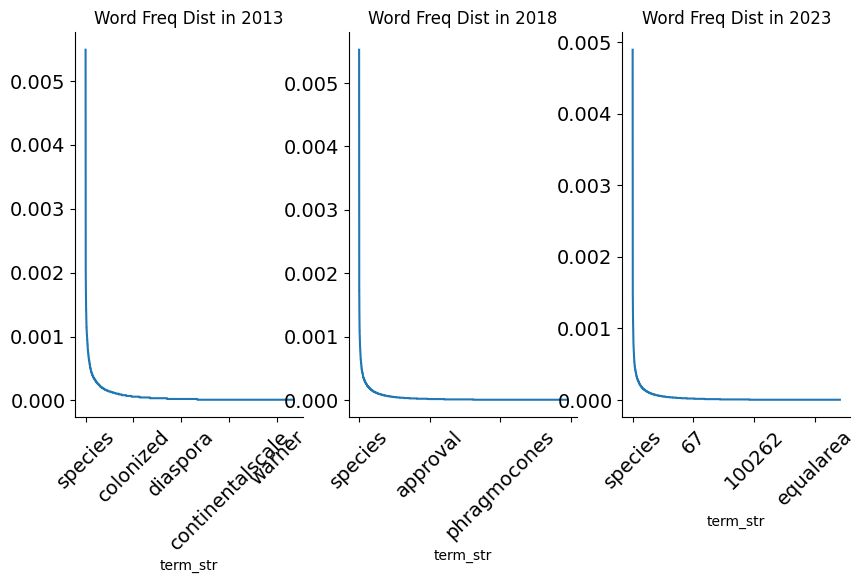

In [16]:
fig1, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].p_yr.plot(ax=axes[i], figsize=(10,5), fontsize=14, rot=45, legend=False, title=f"Word Freq Dist in {year}")
sns.despine()
plt.show()

### Visualization: Most Frequent Words by Year, Stopwords Removed

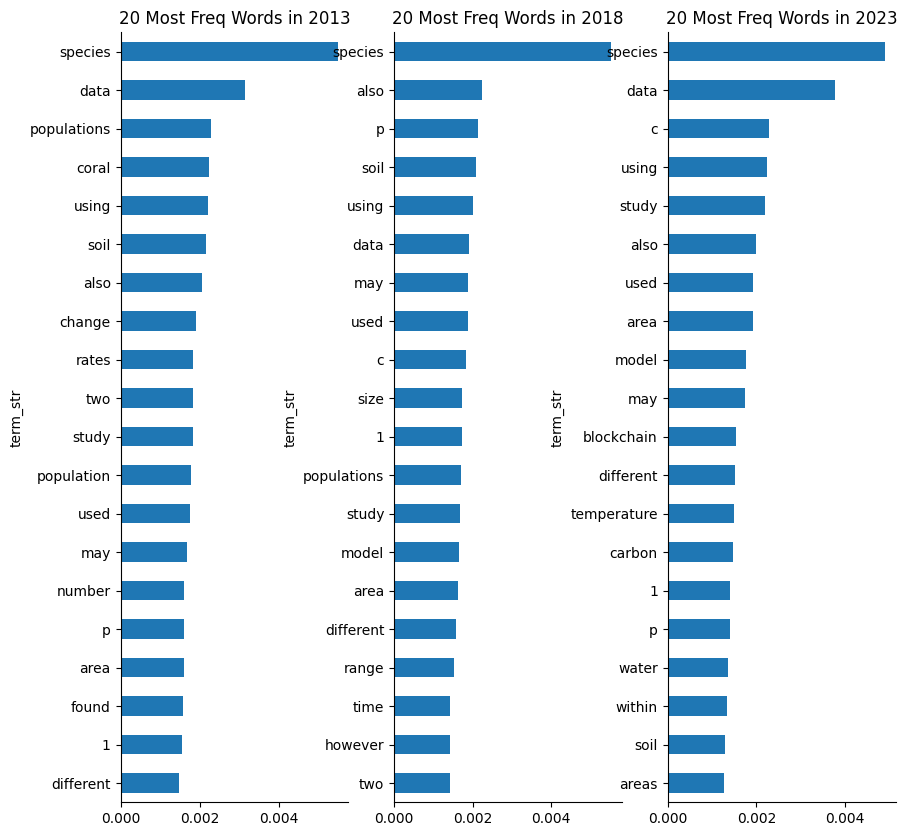

In [17]:
fig2, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].p_yr.head(20).sort_values().plot.barh(ax=axes[i], figsize=(10,10), title=f"20 Most Freq Words in {year}")
sns.despine()
plt.show()

Species is common in both 2013 and 2018 (words like coral, soil, and population dominate 2013 and words like soil and populations predominate in 2018) suggesting a biological bent to the research, while data and blockchain become visible in 2023, suggesting the field may have moved more in a more technological direction.

### Visualization: Per-Word Information Distribution by Year (No Stopwords)

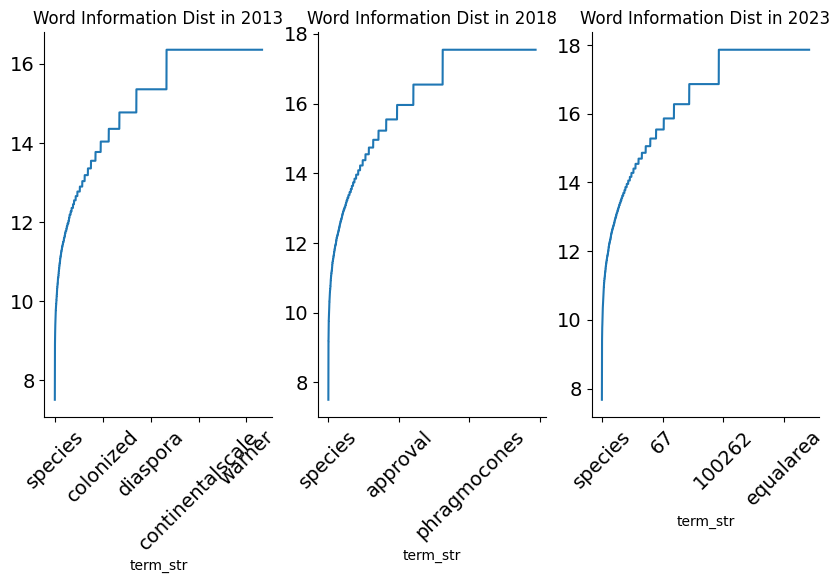

In [18]:
fig3, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].i_yr.plot(ax=axes[i], figsize=(10,5), fontsize=14, rot=45, legend=False, title=f"Word Information Dist in {year}")
sns.despine()
plt.show()

### Visualization: High-Information Words by Year, Stopwords Removed

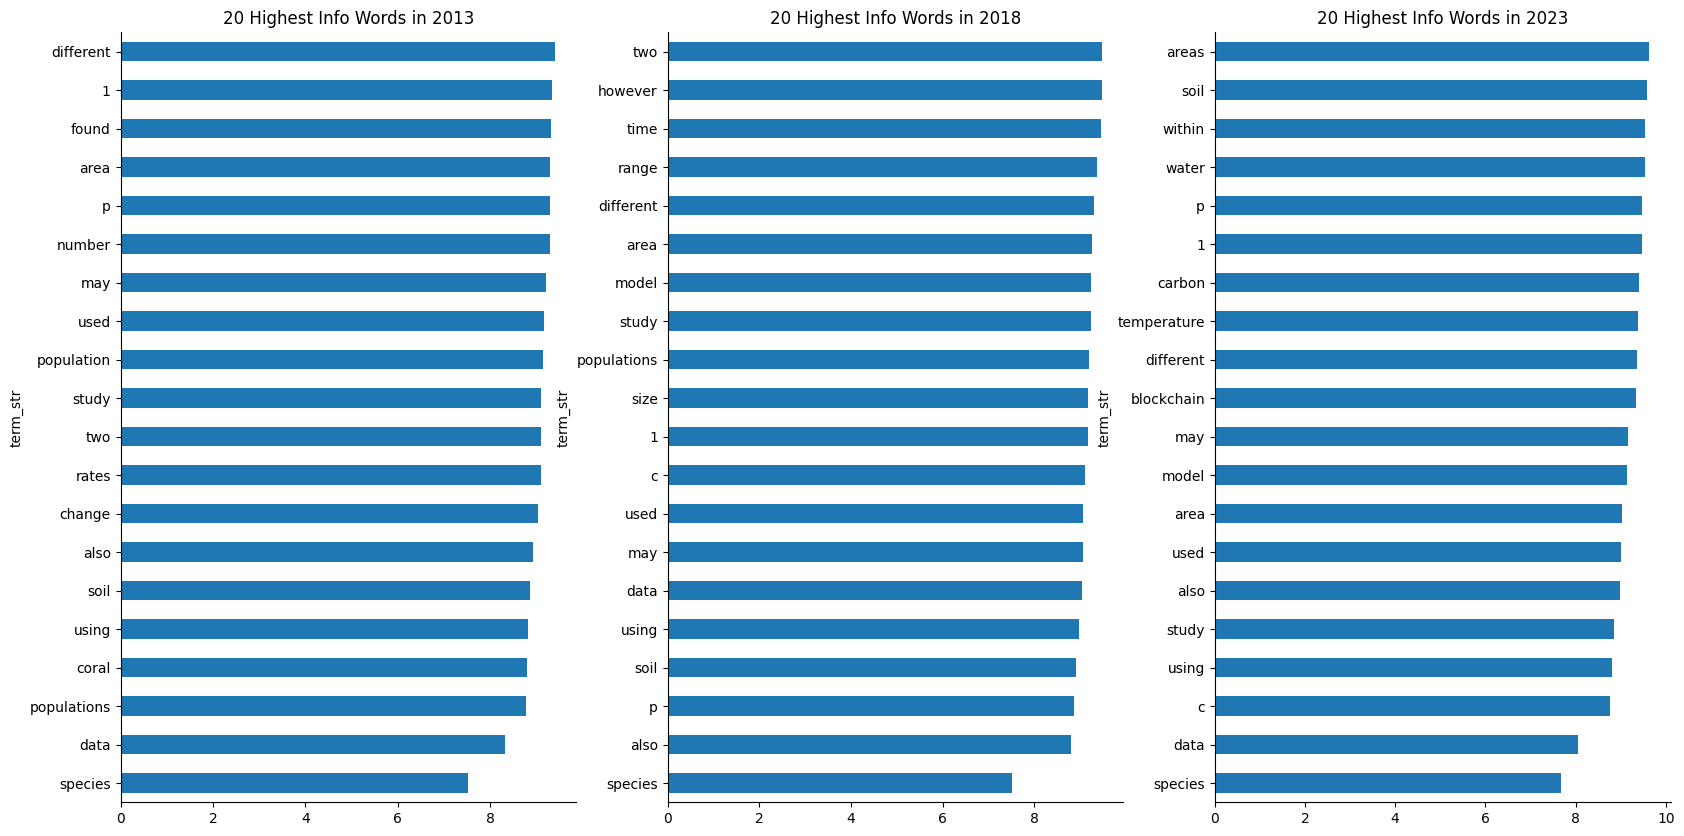

In [19]:
fig4_nosw, axes = plt.subplots(1,3)
for i, year in enumerate(years):
    VOCAB_nosw.loc[year].i_yr.head(20).sort_values().plot.barh(ax=axes[i], figsize=(20,10), title=f"20 Highest Info Words in {year}")
sns.despine()
plt.show()

Once again, biologically-based words such as species, coral, and soil carry high information in 2013, with similarly biological words like populations, soil, and species in 2018. Technologically-based words such as technology and data carry high information in 2023, but words like species and water remain. The trend about which I've hypothesized continues and I look forward to exploring more. 

### File Saving

In [20]:
VOCAB_nosw.to_csv("csvs/VOCAB/VOCAB_nosw", index=False)